# Day 4 – Fund Performance Analytics

This notebook contains performance analysis of mutual funds including:

- Daily Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
import glob

files = glob.glob("../data/raw/*_nav.csv")

files

['../data/raw\\axis_bluechip_nav.csv',
 '../data/raw\\hdfc_top100_nav.csv',
 '../data/raw\\icici_bluechip_nav.csv',
 '../data/raw\\kotak_bluechip_nav.csv',
 '../data/raw\\nippon_largecap_nav.csv',
 '../data/raw\\sbi_bluechip_nav.csv']

In [3]:
import os

nav_list = []

for file in files:

    temp = pd.read_csv(file)

    fund_name = os.path.basename(file).replace("_nav.csv","")

    temp["fund_name"] = fund_name

    nav_list.append(temp)

nav = pd.concat(nav_list, ignore_index=True)

nav.head()

,date,nav,fund_name
0,29-05-2026,6151.1139,axis_bluechip
1,27-05-2026,6146.6118,axis_bluechip
2,26-05-2026,6144.0004,axis_bluechip
3,25-05-2026,6144.8478,axis_bluechip
4,22-05-2026,6142.6380,axis_bluechip


In [4]:
nav["date"] = pd.to_datetime(nav["date"], dayfirst=True)

nav = nav.sort_values(
    ["fund_name", "date"]
)

nav.head()

,date,nav,fund_name
3563,2012-12-31,23.9920,axis_bluechip
3562,2013-01-01,23.9979,axis_bluechip
3561,2013-01-02,24.0036,axis_bluechip
3560,2013-01-03,24.0092,axis_bluechip
3559,2013-01-04,24.0147,axis_bluechip


In [5]:
nav["daily_return"] = (
    nav.groupby("fund_name")["nav"]
       .pct_change()
)

nav.head()

,date,nav,fund_name,daily_return
3563,2012-12-31,23.9920,axis_bluechip,NaN
3562,2013-01-01,23.9979,axis_bluechip,0.000246
3561,2013-01-02,24.0036,axis_bluechip,0.000238
3560,2013-01-03,24.0092,axis_bluechip,0.000233
3559,2013-01-04,24.0147,axis_bluechip,0.000229


In [6]:
import numpy as np

nav["daily_return"] = nav["daily_return"].replace(
    [np.inf, -np.inf],
    np.nan
)

nav["daily_return"].describe()

count    19785.000000
mean         0.005475
std          0.704212
min         -1.000000
25%         -0.001100
50%          0.000263
75%          0.003261
max         99.042353
Name: daily_return, dtype: float64

In [7]:
nav["daily_return"].isna().sum()

7

In [8]:
nav["daily_return"].max()

99.04235339273836

In [9]:
nav["daily_return"].nlargest(10)

2758     99.042353
17025     0.128260
11474     0.070446
14774     0.070415
11484     0.069029
8176      0.065615
8308      0.062809
11606     0.061941
14906     0.060898
8183      0.051043
Name: daily_return, dtype: float64

In [10]:
nav[nav["daily_return"] > 1]

,date,nav,fund_name,daily_return
2758,2015-08-30,3023.47,axis_bluechip,99.042353


In [11]:
nav = nav[
    (nav["daily_return"] > -1) &
    (nav["daily_return"] < 1)
]

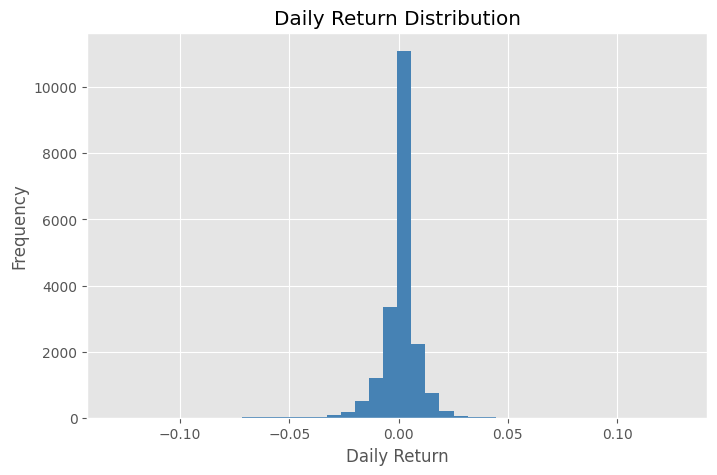

In [12]:
plt.figure(figsize=(8,5))

nav["daily_return"].dropna().hist(
    bins=40,
    color="steelblue"
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.savefig("../reports/daily_return_distribution.png")
plt.show()

In [13]:
nav.to_csv(
    "../data/processed/nav_returns.csv",
    index=False
)

## Daily Return Distribution Analysis

The histogram shows that most mutual fund daily returns are concentrated around zero, indicating relatively stable day-to-day performance. The distribution appears approximately normal with a slight spread on both positive and negative sides. Extreme return events are rare, suggesting limited daily volatility across the selected funds. This behavior is expected for diversified mutual fund portfolios and provides a suitable basis for risk-adjusted performance analysis.

# CAGR Analysis

Compute and compare 1-Year, 3-Year, and 5-Year Compound Annual Growth Rate (CAGR) across all mutual fund schemes.

In [14]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["fund_name", "date"])

In [15]:
nav.groupby("fund_name")["date"].agg(["min", "max"])

,min,max
fund_name,,
axis_bluechip,2013-01-01,2026-05-29
hdfc_top100,2013-11-19,2026-05-31
icici_bluechip,2013-01-03,2026-05-31
kotak_bluechip,2013-01-08,2026-05-29
nippon_largecap,2013-01-03,2026-05-29
sbi_bluechip,2013-01-03,2026-05-29


## CAGR Analysis

Compound Annual Growth Rate (CAGR) measures the annualized return of an investment over a specified period. It smooths out yearly fluctuations and provides a standardized measure for comparing long-term fund performance.

In [16]:
def calculate_cagr(group, years):
    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    subset = group[group["date"] >= start_date]

    if len(subset) < 2:
        return np.nan

    start_nav = subset.iloc[0]["nav"]
    end_nav = subset.iloc[-1]["nav"]

    return (end_nav / start_nav) ** (1 / years) - 1

In [17]:
cagr_results = []

for fund, group in nav.groupby("fund_name"):

    cagr_results.append({
        "fund_name": fund,
        "cagr_1y": calculate_cagr(group, 1),
        "cagr_3y": calculate_cagr(group, 3),
        "cagr_5y": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df

,fund_name,cagr_1y,cagr_3y,cagr_5y
0,axis_bluechip,0.059508,0.072541,0.064301
1,hdfc_top100,0.005217,0.135500,0.147426
2,icici_bluechip,-0.024943,0.113380,0.082282
3,kotak_bluechip,0.012507,0.190942,0.186308
4,nippon_largecap,-0.009740,0.151227,0.159885
5,sbi_bluechip,-0.028149,-0.022929,-0.075374


In [18]:
cagr_df[["cagr_1y", "cagr_3y", "cagr_5y"]] = (
    cagr_df[["cagr_1y", "cagr_3y", "cagr_5y"]] * 100
)

cagr_df.round(2)

,fund_name,cagr_1y,cagr_3y,cagr_5y
0,axis_bluechip,5.95,7.25,6.43
1,hdfc_top100,0.52,13.55,14.74
2,icici_bluechip,-2.49,11.34,8.23
3,kotak_bluechip,1.25,19.09,18.63
4,nippon_largecap,-0.97,15.12,15.99
5,sbi_bluechip,-2.81,-2.29,-7.54


In [19]:
cagr_df.to_csv(
    "../reports/fund_cagr.csv",
    index=False
)

<Figure size 1000x600 with 0 Axes>

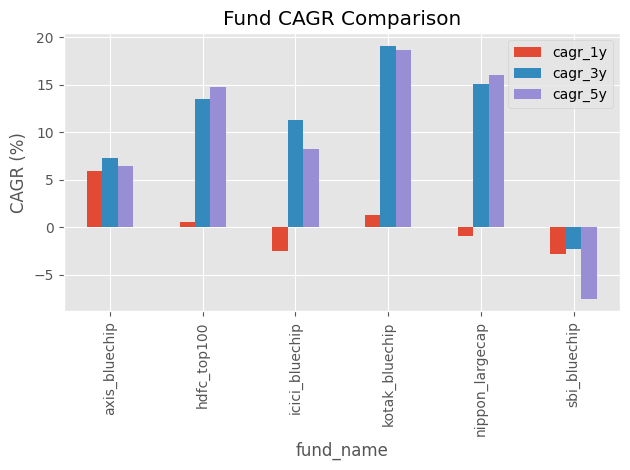

In [20]:
plt.figure(figsize=(10,6))

cagr_df.set_index("fund_name")[["cagr_1y","cagr_3y","cagr_5y"]].plot(
    kind="bar"
)

plt.title("Fund CAGR Comparison")
plt.ylabel("CAGR (%)")

plt.tight_layout()

plt.savefig("../reports/cagr_comparison.png")

plt.show()

## CAGR Analysis Insights

The CAGR comparison reveals significant differences in long-term fund performance. Kotak Bluechip achieved the highest CAGR across multiple investment horizons, indicating strong wealth creation potential. Nippon Largecap and HDFC Top 100 also demonstrated consistent long-term growth. Axis Bluechip delivered moderate returns, while SBI Bluechip showed negative CAGR values, reflecting weaker performance over the analyzed periods. Overall, long-term CAGR highlights the importance of fund selection for maximizing investment returns.

# Sharpe Ratio Analysis

The Sharpe Ratio measures risk-adjusted performance by comparing excess return over the risk-free rate relative to total volatility. Higher Sharpe Ratios indicate better returns per unit of risk.

In [21]:
risk_free_rate = 0.065

sharpe_results = []

for fund, group in nav.groupby("fund_name"):

    returns = group["daily_return"].dropna()

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - risk_free_rate)
        / annual_volatility
        if annual_volatility != 0
        else np.nan
    )

    sharpe_results.append({
        "fund_name": fund,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

,fund_name,sharpe_ratio
1,hdfc_top100,1.094724
3,kotak_bluechip,0.693757
2,icici_bluechip,0.618958
4,nippon_largecap,0.565958
0,axis_bluechip,0.297699
5,sbi_bluechip,-0.686447


In [22]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

<Figure size 800x500 with 0 Axes>

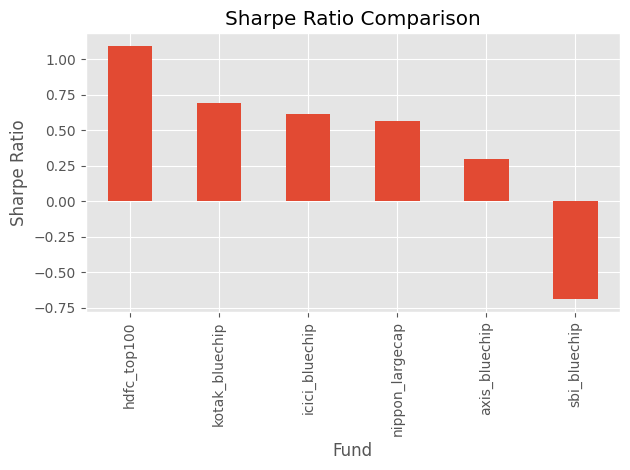

In [23]:
plt.figure(figsize=(8,5))

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).plot(
    x="fund_name",
    y="sharpe_ratio",
    kind="bar",
    legend=False
)

plt.title("Sharpe Ratio Comparison")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Fund")

plt.tight_layout()

plt.savefig("../reports/sharpe_ratio.png")

plt.show()

## Sharpe Ratio Analysis

The Sharpe Ratio comparison evaluates fund performance relative to the level of risk undertaken. HDFC Top 100 achieved the highest Sharpe Ratio, indicating the most efficient balance between return and volatility. Kotak Bluechip and ICICI Bluechip also demonstrated strong risk-adjusted performance. SBI Bluechip recorded a negative Sharpe Ratio, suggesting that its returns did not adequately compensate investors for the associated risk.

# Sortino Ratio Analysis

The Sortino Ratio measures risk-adjusted return while considering only downside volatility.

In [24]:
sortino_results = []

for fund, group in nav.groupby("fund_name"):

    returns = group["daily_return"].dropna()

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    if downside_std > 0:
        sortino = (annual_return - risk_free_rate) / downside_std
    else:
        sortino = np.nan

    sortino_results.append({
        "fund_name": fund,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df

,fund_name,sortino_ratio
1,hdfc_top100,1.324628
3,kotak_bluechip,0.806483
2,icici_bluechip,0.769371
4,nippon_largecap,0.701309
0,axis_bluechip,0.148140
5,sbi_bluechip,-0.389119


In [25]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

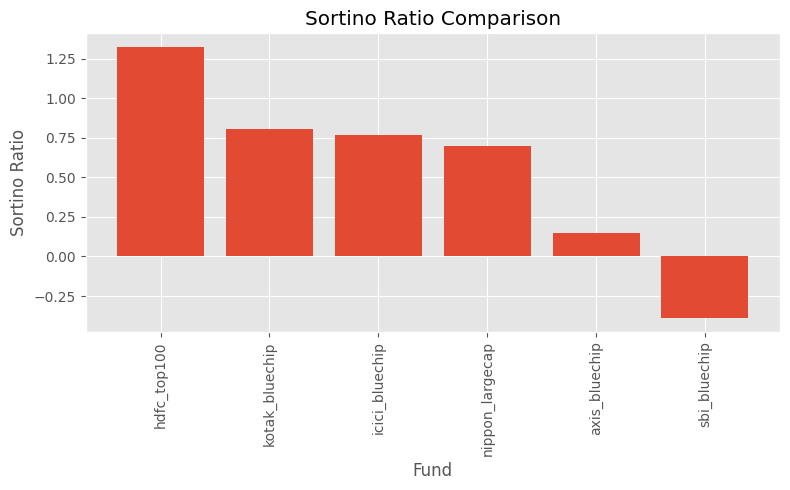

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    sortino_df["fund_name"],
    sortino_df["sortino_ratio"]
)

plt.title("Sortino Ratio Comparison")
plt.ylabel("Sortino Ratio")
plt.xlabel("Fund")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("../reports/sortino_ratio.png")

plt.show()

## Sortino Ratio Conclusion

The Sortino Ratio analysis shows the risk-adjusted performance of mutual funds considering only downside volatility.

- HDFC Top 100 achieved the highest Sortino Ratio, indicating the best return relative to downside risk.
- Kotak Bluechip, ICICI Bluechip, and Nippon Large Cap also demonstrated strong downside risk-adjusted performance.
- Axis Bluechip showed moderate performance.
- SBI Bluechip recorded a negative Sortino Ratio, suggesting that returns were insufficient to compensate for downside risk.

Overall, funds with higher Sortino Ratios exhibited better downside risk management and more efficient return generation.

# Alpha and Beta Analysis

Alpha measures excess return generated by a fund compared to the benchmark after adjusting for market risk.

Beta measures the sensitivity of a fund's returns relative to benchmark returns.

- Beta > 1 : More volatile than benchmark
- Beta < 1 : Less volatile than benchmark
- Positive Alpha : Outperformed benchmark
- Negative Alpha : Underperformed benchmark

In [27]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [28]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [29]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
][["date", "benchmark_return"]]

nifty50.head()

,date,benchmark_return
0,2022-01-03,NaN
1,2022-01-04,0.011253
2,2022-01-05,0.008220
3,2022-01-06,0.002437
4,2022-01-07,-0.006676


In [30]:
alpha_beta_results = []

In [31]:
from scipy.stats import linregress

for fund in nav["fund_name"].unique():

    fund_data = nav[
        nav["fund_name"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty50,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    beta, alpha, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = alpha * 252

    alpha_beta_results.append({
        "fund_name": fund,
        "alpha": alpha,
        "beta": beta
    })

In [32]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df

,fund_name,alpha,beta
0,axis_bluechip,0.068308,0.001652
1,hdfc_top100,0.126532,-0.028615
2,icici_bluechip,0.065962,-0.017920
3,kotak_bluechip,0.173563,0.001721
4,nippon_largecap,0.148572,-0.006273
5,sbi_bluechip,-0.031185,0.060558


In [33]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

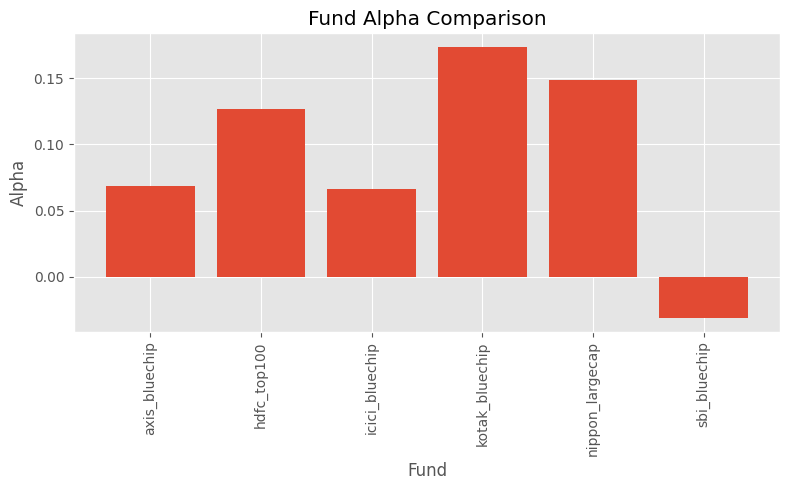

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    alpha_beta_df["fund_name"],
    alpha_beta_df["alpha"]
)

plt.title("Fund Alpha Comparison")
plt.xlabel("Fund")
plt.ylabel("Alpha")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("../reports/alpha_comparison.png")

plt.show()

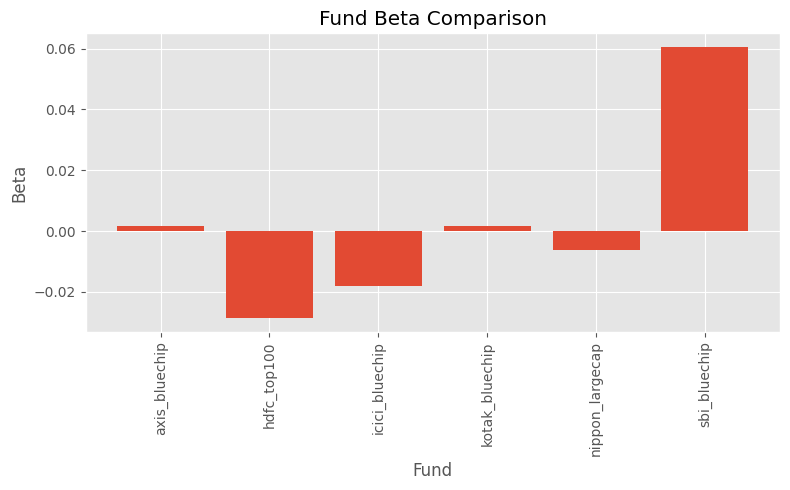

In [35]:
plt.figure(figsize=(8,5))

plt.bar(
    alpha_beta_df["fund_name"],
    alpha_beta_df["beta"]
)

plt.title("Fund Beta Comparison")
plt.xlabel("Fund")
plt.ylabel("Beta")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("../reports/beta_comparison.png")

plt.show()

In [36]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

## Alpha and Beta Analysis Conclusion

- Kotak Bluechip recorded the highest Alpha, indicating the strongest excess return relative to the benchmark.
- Nippon Largecap and HDFC Top 100 also generated positive Alpha values, suggesting benchmark outperformance.
- SBI Bluechip recorded a negative Alpha, indicating underperformance relative to the benchmark.

### Beta Interpretation

- All funds exhibited Beta values close to zero, suggesting weak correlation with the benchmark returns used in this analysis.
- SBI Bluechip recorded the highest positive Beta among the selected funds.
- HDFC Top 100 and ICICI Bluechip showed negative Beta values, indicating inverse movement relative to benchmark returns during the observed period.



# Maximum Drawdown Analysis

Maximum Drawdown (MDD) measures the largest peak-to-trough decline experienced by a fund.

Lower drawdown indicates better capital preservation during market downturns.

In [37]:
mdd_results = []

for fund in nav["fund_name"].unique():

    fund_data = nav[
        nav["fund_name"] == fund
    ].sort_values("date")

    cumulative_nav = fund_data["nav"]

    rolling_max = cumulative_nav.cummax()

    drawdown = (
        cumulative_nav - rolling_max
    ) / rolling_max

    max_drawdown = drawdown.min()

    mdd_results.append({
        "fund_name": fund,
        "max_drawdown": max_drawdown
    })

mdd_df = pd.DataFrame(mdd_results)

mdd_df = mdd_df.sort_values(
    "max_drawdown"
)

mdd_df

,fund_name,max_drawdown
1,hdfc_top100,-0.402601
4,nippon_largecap,-0.399608
5,sbi_bluechip,-0.366517
2,icici_bluechip,-0.335099
3,kotak_bluechip,-0.334299
0,axis_bluechip,-0.013924


In [38]:
nav[
    nav["fund_name"] == "axis_bluechip"
]["nav"].describe()

count    3562.000000
mean     3391.244305
std      1978.597536
min        23.997900
25%      3090.124850
50%      3848.407350
75%      4748.170000
max      6151.867100
Name: nav, dtype: float64

In [39]:
nav["fund_name"].value_counts()

fund_name
axis_bluechip      3562
icici_bluechip     3303
kotak_bluechip     3299
nippon_largecap    3296
sbi_bluechip       3234
hdfc_top100        3089
Name: count, dtype: int64

In [40]:
fund_data = nav[
    nav["fund_name"] == "axis_bluechip"
].sort_values("date")

rolling_max = fund_data["nav"].cummax()

drawdown = (
    fund_data["nav"] - rolling_max
) / rolling_max

drawdown.describe()

count    3562.000000
mean       -0.000042
std         0.000463
min        -0.013924
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
Name: nav, dtype: float64

In [41]:
drawdown.min()

-0.013923580128646426

In [42]:
mdd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

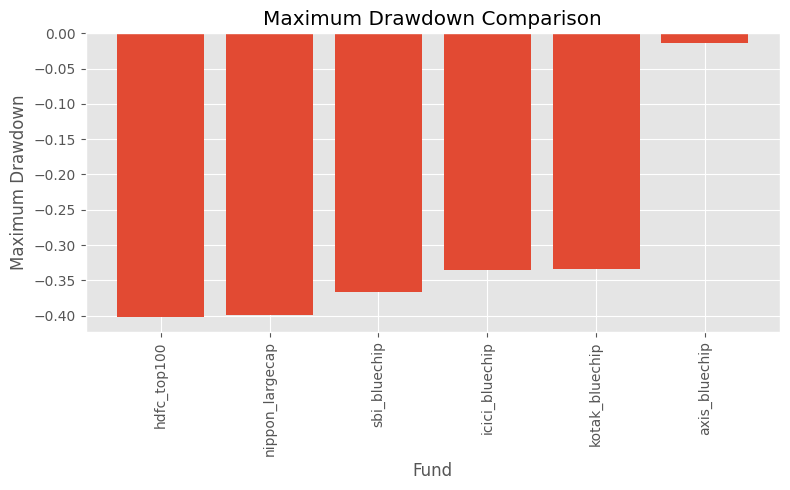

In [43]:
plt.figure(figsize=(8,5))

plt.bar(
    mdd_df["fund_name"],
    mdd_df["max_drawdown"]
)

plt.title("Maximum Drawdown Comparison")
plt.xlabel("Fund")
plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/max_drawdown.png"
)

plt.show()

## Maximum Drawdown Conclusion

- HDFC Top 100 recorded the highest drawdown, indicating the largest decline from its peak value.
- Nippon Largecap and SBI Bluechip also experienced substantial drawdowns during the analysis period.
- Axis Bluechip recorded the lowest drawdown, demonstrating strong capital preservation and lower downside risk.

Overall, lower drawdown values indicate better resilience during market downturns. Axis Bluechip exhibited the strongest downside protection among the selected funds.

## Worst Drawdown Date Range Analysis

This section identifies the peak-to-trough period corresponding to the maximum drawdown for each fund.

In [44]:
drawdown_ranges = []

for fund in nav["fund_name"].unique():

    fund_data = nav[
        nav["fund_name"] == fund
    ].sort_values("date").copy()

    fund_data["running_max"] = fund_data["nav"].cummax()

    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
        - 1
    )

    worst_idx = fund_data["drawdown"].idxmin()

    worst_row = fund_data.loc[worst_idx]

    peak_nav = worst_row["running_max"]

    peak_date = fund_data[
        fund_data["nav"] == peak_nav
    ]["date"].iloc[0]

    drawdown_ranges.append({
        "fund_name": fund,
        "peak_date": peak_date,
        "trough_date": worst_row["date"],
        "max_drawdown": worst_row["drawdown"]
    })

drawdown_ranges_df = pd.DataFrame(drawdown_ranges)

drawdown_ranges_df

,fund_name,peak_date,trough_date,max_drawdown
0,axis_bluechip,2020-03-11,2020-03-24,-0.013924
1,hdfc_top100,2018-01-08,2020-03-24,-0.402601
2,icici_bluechip,2020-02-12,2020-03-23,-0.335099
3,kotak_bluechip,2020-01-29,2020-03-23,-0.334299
4,nippon_largecap,2019-05-27,2020-03-23,-0.399608
5,sbi_bluechip,2021-01-08,2024-12-20,-0.366517


In [45]:
drawdown_ranges_df.to_csv(
    "../reports/drawdown_ranges.csv",
    index=False
)

## Worst Drawdown Period Analysis

- Most funds recorded their worst drawdowns during the March 2020 market crash.
- HDFC Top 100 and Nippon Largecap experienced the deepest declines, exceeding 39%.
- SBI Bluechip recorded its worst drawdown over a longer period between 2021 and 2024.
- Axis Bluechip experienced the smallest drawdown among the analyzed funds.

Overall, the results highlight how different funds reacted to major market downturns and recovery cycles.

# Fund Scorecard Analysis

A composite score was created to rank funds using multiple performance and risk metrics.

Scoring Weights:
- 30% : 3-Year Return Rank
- 25% : Sharpe Ratio Rank
- 20% : Alpha Rank
- 15% : Expense Ratio Rank (Lower is Better)
- 10% : Maximum Drawdown Rank (Lower Drawdown is Better)

Higher scores indicate stronger overall performance after considering returns, risk-adjusted returns, expenses, and downside risk.

In [46]:
expense_ratio_df = pd.read_csv("../data/processed/scheme_performance_clean.csv")

expense_ratio_df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [47]:
scorecard = expense_ratio_df.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(
    ascending=False
)

scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

scorecard["fund_score"] = (
    scorecard["fund_score"] /
    scorecard["fund_score"].max()
) * 100

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[
    ["scheme_name", "fund_score"]
].head()

,scheme_name,fund_score
36,Mirae Asset Tax Saver Fund - Regular - Growth,100.000000
10,ICICI Pru Bluechip Fund - Regular - Growth,98.070988
24,Axis Bluechip Fund - Regular - Growth,92.206790
0,SBI Bluechip Fund - Regular Plan - Growth,85.030864
31,UTI Nifty 50 Index Fund - Regular - Growth,83.873457


In [48]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

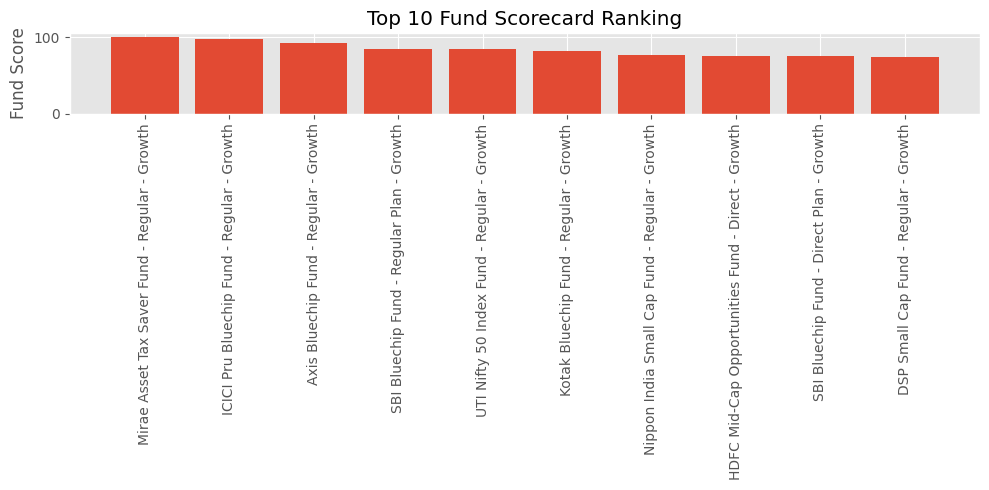

In [49]:
plt.figure(figsize=(10,5))

top_funds = scorecard.head(10)

plt.bar(
    top_funds["scheme_name"],
    top_funds["fund_score"]
)

plt.title("Top 10 Fund Scorecard Ranking")
plt.ylabel("Fund Score")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/fund_scorecard.png"
)

plt.show()

# Fund Scorecard Conclusion

The composite scorecard ranked funds using a weighted combination of 3-Year Returns, Sharpe Ratio, Alpha, Expense Ratio, and Maximum Drawdown.

Key Findings:

- Mirae Asset Tax Saver Fund achieved the highest overall score.
- ICICI Prudential Bluechip Fund and Axis Bluechip Fund also ranked among the strongest performers.
- Higher-ranked funds demonstrated a balance between strong returns, favorable risk-adjusted performance, and controlled drawdowns.
- Funds with weaker Sharpe Ratios, lower Alpha values, or higher expenses received lower composite scores.



# Benchmark Comparison Analysis

The benchmark comparison was performed using the funds for which complete NAV history was available.

Benchmarks:
- NIFTY50
- NIFTY100

The objective is to compare cumulative growth and evaluate how closely each fund tracked the benchmark indices.

In [50]:
end_date = nav["date"].max()

start_date = end_date - pd.DateOffset(years=3)

print("Start Date:", start_date)
print("End Date:", end_date)

Start Date: 2023-05-31 00:00:00
End Date: 2026-05-31 00:00:00


In [51]:
funds = [
    "axis_bluechip",
    "hdfc_top100",
    "icici_bluechip",
    "kotak_bluechip",
    "nippon_largecap",
    "sbi_bluechip"
]

In [52]:
start_date = end_date - pd.DateOffset(years=3)

In [53]:
nifty50_3yr = benchmark[
    (benchmark["index_name"] == "NIFTY50") &
    (benchmark["date"] >= start_date)
].copy()

nifty100_3yr = benchmark[
    (benchmark["index_name"] == "NIFTY100") &
    (benchmark["date"] >= start_date)
].copy()

nifty50_3yr["growth"] = (
    nifty50_3yr["close_value"] /
    nifty50_3yr["close_value"].iloc[0]
)

nifty100_3yr["growth"] = (
    nifty100_3yr["close_value"] /
    nifty100_3yr["close_value"].iloc[0]
)

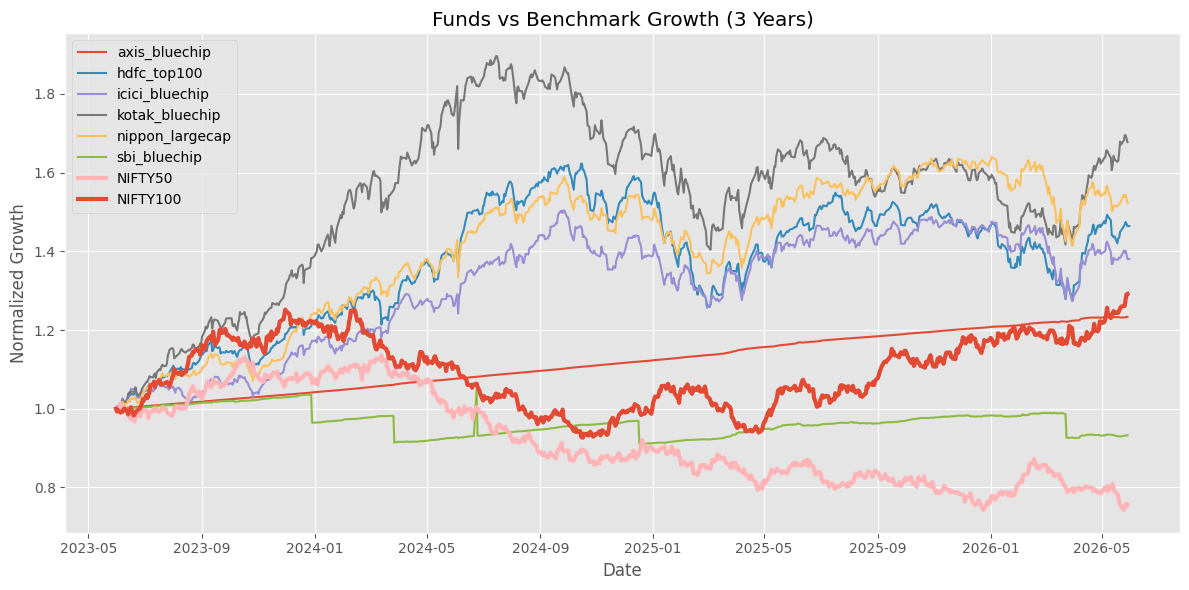

In [54]:
plt.figure(figsize=(12,6))

for fund in funds:

    temp = nav[
        (nav["fund_name"] == fund) &
        (nav["date"] >= start_date)
    ].copy()

    temp = temp.sort_values("date")

    temp["growth"] = (
        temp["nav"] /
        temp["nav"].iloc[0]
    )

    plt.plot(
        temp["date"],
        temp["growth"],
        label=fund
    )

plt.plot(
    nifty50_3yr["date"],
    nifty50_3yr["growth"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100_3yr["date"],
    nifty100_3yr["growth"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Funds vs Benchmark Growth (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Growth")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()

# Tracking Error Analysis

Tracking Error measures how closely a fund follows its benchmark.

Formula:

Tracking Error = std(fund_return - benchmark_return) × √252

In [55]:
tracking_error_results = []

for fund in funds:

    fund_data = nav[
        (nav["fund_name"] == fund) &
        (nav["date"] >= start_date)
    ].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["fund_return"] = fund_data["nav"].pct_change()

    merged = pd.merge(
        fund_data[["date", "fund_return"]],
        nifty100_3yr[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    tracking_error = (
        (merged["fund_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error_results.append(
        [fund, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=["fund_name", "tracking_error"]
)

tracking_error_df.sort_values(
    "tracking_error"
)

,fund_name,tracking_error
0,axis_bluechip,0.128383
5,sbi_bluechip,0.176045
2,icici_bluechip,0.184790
4,nippon_largecap,0.185913
1,hdfc_top100,0.189814
3,kotak_bluechip,0.208041


In [56]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

tracking_error_df.head()

,fund_name,tracking_error
0,axis_bluechip,0.128383
1,hdfc_top100,0.189814
2,icici_bluechip,0.184790
3,kotak_bluechip,0.208041
4,nippon_largecap,0.185913


# Benchmark Comparison Conclusion

The benchmark comparison evaluated how selected mutual funds performed against the NIFTY50 and NIFTY100 indices over the last three years.

### Key Findings

- Kotak Bluechip and Nippon Largecap generated the strongest cumulative growth.
- HDFC Top 100 also outperformed benchmark indices during much of the analysis period.
- NIFTY100 delivered relatively stable benchmark growth and served as a useful market reference.
- Tracking Error analysis highlighted how closely each fund followed benchmark movements.
- Funds with lower tracking error behaved more like passive index strategies, while higher tracking error suggested greater active management decisions.